# Session 3 — Concepts RAG Systems
**GenAI 403 | Global Track**

---
### Session Objectives
- Learn **Retrieval-Augmented Generation (RAG)** conceptually
- Implement local RAG using **FAISS** and **Chroma**
- Understand **retriever-score**, **re-ranking**, and **hallucination resistance**
- Build an **end-to-end RAG pipeline** in LangChain
- Ingest documents and generate embeddings (HuggingFace — free)

### Tools Used (All Free)
- `langchain` + `langchain-community` — RAG pipeline framework
- `faiss-cpu` — Facebook AI fast vector search
- `chromadb` — Local vector database
- `sentence-transformers` — Free HuggingFace embeddings
- `transformers` — Free HuggingFace generation model
---

## Step 0 — Install Required Libraries

In [2]:
%pip install langchain langchain-community langchain-huggingface faiss-cpu chromadb sentence-transformers transformers torch --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [18]:
%pip install matplotlib
%pip install seaborn



1273.16s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 4.7 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [seaborn]m1/2 [seaborn]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Step 1 — Import Libraries

In [5]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

print("All libraries imported!")

All libraries imported!


---
## Part 1 — What is RAG? (Conceptual Overview)

A standard LLM only knows what it was trained on — it **cannot access new documents**.

**RAG fixes this by:**
1. Splitting documents into chunks
2. Embedding chunks into a vector store
3. At query time: retrieving the most relevant chunks
4. Feeding retrieved chunks + question into the LLM

```
User Question
      ↓
  [Embedder]
      ↓
[Vector Store] → Top-K relevant chunks
      ↓
[LLM Prompt: context + question]
      ↓
   Answer
```

This prevents **hallucination** because the model answers from real retrieved text.

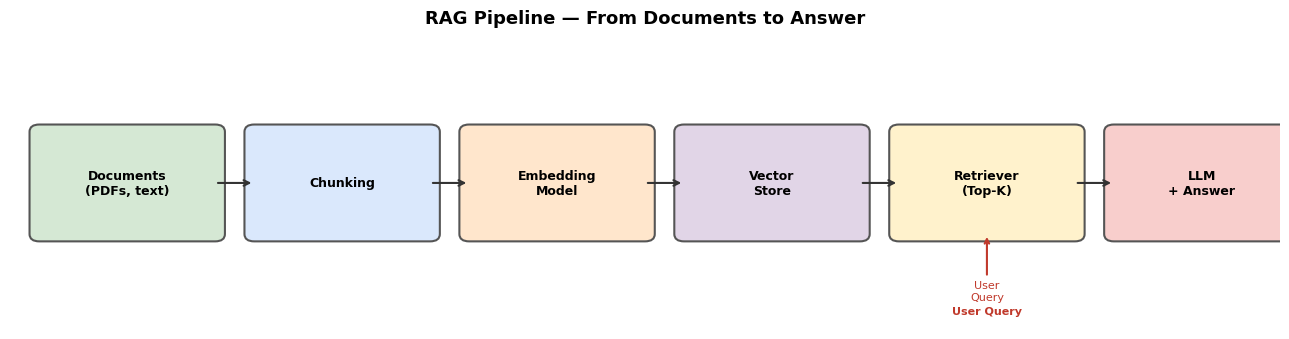

In [14]:
# Visualize the RAG pipeline as a flow diagram
fig, ax = plt.subplots(figsize=(13, 3.5))
ax.set_xlim(0, 13)
ax.set_ylim(0, 4)
ax.axis("off")

steps = [
    (0.3,  "Documents\n(PDFs, text)"),
    (2.5,  "Chunking"),
    (4.7,  "Embedding\nModel"),
    (6.9,  "Vector\nStore"),
    (9.1,  "Retriever\n(Top-K)"),
    (11.3, "LLM\n+ Answer"),
]

box_colors = ["#d5e8d4", "#dae8fc", "#ffe6cc", "#e1d5e7", "#fff2cc", "#f8cecc"]

for (x, label), color in zip(steps, box_colors):
    rect = mpatches.FancyBboxPatch((x, 1.3), 1.8, 1.4,
        boxstyle="round,pad=0.1", linewidth=1.5,
        edgecolor="#555", facecolor=color)
    ax.add_patch(rect)
    ax.text(x + 0.9, 2.0, label, ha="center", va="center",
            fontsize=9, fontweight="bold")

# Arrows between boxes
for i in range(len(steps) - 1):
    x_start = steps[i][0] + 1.8
    x_end   = steps[i+1][0]
    ax.annotate("", xy=(x_end, 2.0), xytext=(x_start, 2.0),
                arrowprops=dict(arrowstyle="->", color="#333", lw=1.5))

# User query arrow into Retriever
ax.annotate("User\nQuery", xy=(9.1 + 0.9, 1.3), xytext=(9.1 + 0.9, 0.4),
            ha="center", fontsize=8, color="#c0392b",
            arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1.5))
ax.text(9.1 + 0.9, 0.2, "User Query", ha="center", fontsize=8,
        color="#c0392b", fontweight="bold")

ax.set_title("RAG Pipeline — From Documents to Answer", fontsize=13,
             fontweight="bold", pad=10)
plt.tight_layout()
plt.show()

---
## Part 2 — Document Ingestion and Chunking

Before we can search documents, we need to:
1. **Load** the text
2. **Split** it into overlapping chunks (so context is not lost at boundaries)

We use `RecursiveCharacterTextSplitter` from LangChain.

In [2]:
#from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_text_splitters import RecursiveCharacterTextSplitter


# Sample knowledge base (simulates ingesting a document)
sample_document = """
Artificial intelligence (AI) is intelligence demonstrated by machines.
AI research has been defined as the field of study of intelligent agents.
Machine learning is a subset of AI that allows systems to learn from data.
Deep learning uses neural networks with many layers to learn representations.
Large language models (LLMs) are trained on vast amounts of text data.
LLMs like GPT-4, LLaMA, and Claude can generate human-like text.
Retrieval-Augmented Generation (RAG) combines retrieval with generation.
RAG fetches relevant documents before generating an answer.
This reduces hallucinations and keeps answers grounded in real sources.
Vector databases store embeddings for fast similarity search.
FAISS is a library by Facebook AI for efficient similarity search.
Chroma is an open-source embedding database for AI applications.
Embeddings are dense numerical representations of text meaning.
Cosine similarity measures how close two embeddings are in vector space.
Re-ranking improves retrieval by scoring candidates with a cross-encoder.
Hallucination in LLMs refers to generating confident but incorrect facts.
RAG is one of the most effective methods to reduce hallucination.
"""

splitter = RecursiveCharacterTextSplitter(
    chunk_size=200,
    chunk_overlap=100,
    separators=["\n", ". ", " "]
)

chunks = splitter.split_text(sample_document.strip())

print("Total chunks created:", len(chunks))
print()
for i, chunk in enumerate(chunks):
    print(f"Chunk {i+1} ({len(chunk)} chars):")
    print(" ", chunk)
    print()

Total chunks created: 13

Chunk 1 (144 chars):
  Artificial intelligence (AI) is intelligence demonstrated by machines.
AI research has been defined as the field of study of intelligent agents.

Chunk 2 (148 chars):
  AI research has been defined as the field of study of intelligent agents.
Machine learning is a subset of AI that allows systems to learn from data.

Chunk 3 (152 chars):
  Machine learning is a subset of AI that allows systems to learn from data.
Deep learning uses neural networks with many layers to learn representations.

Chunk 4 (148 chars):
  Deep learning uses neural networks with many layers to learn representations.
Large language models (LLMs) are trained on vast amounts of text data.

Chunk 5 (135 chars):
  Large language models (LLMs) are trained on vast amounts of text data.
LLMs like GPT-4, LLaMA, and Claude can generate human-like text.

Chunk 6 (197 chars):
  LLMs like GPT-4, LLaMA, and Claude can generate human-like text.
Retrieval-Augmented Generation (RA

---
## Part 3 — Generating Embeddings (Free HuggingFace Model)

Each chunk is converted into a **dense vector** using a sentence-transformer model.
We use `all-MiniLM-L6-v2` — free, fast, 384 dimensions.

In [6]:
from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer("all-MiniLM-L6-v2")

# Generate embeddings for all chunks
embeddings_tensor = embed_model.encode(chunks, convert_to_tensor=True, show_progress_bar=True)
chunk_embeddings = np.array(embeddings_tensor.float().cpu().tolist())

print("Embeddings shape:", chunk_embeddings.shape)
print("Each chunk → vector of", chunk_embeddings.shape[1], "dimensions")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5973.39it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 1/1 [00:00<00:00, 29.46it/s]

Embeddings shape: (13, 384)
Each chunk → vector of 384 dimensions


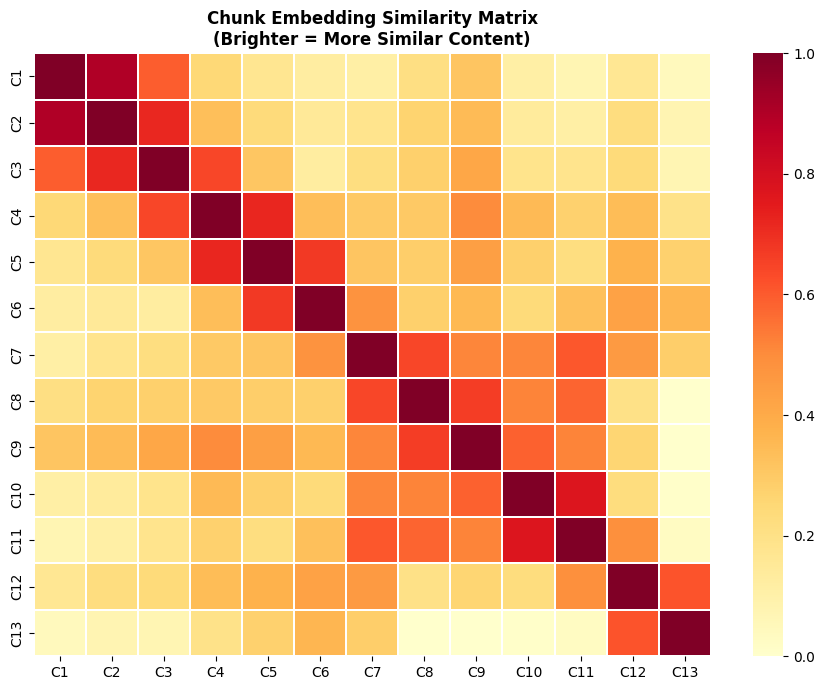

Tip: Chunks about similar topics (e.g., FAISS and Chroma) have higher similarity.


In [7]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns

# Compute pairwise cosine similarity between all chunks
sim_matrix = cosine_similarity(chunk_embeddings)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(sim_matrix, annot=False, cmap="YlOrRd",
            xticklabels=[f"C{i+1}" for i in range(len(chunks))],
            yticklabels=[f"C{i+1}" for i in range(len(chunks))],
            linewidths=0.3, ax=ax, vmin=0, vmax=1)
ax.set_title("Chunk Embedding Similarity Matrix\n(Brighter = More Similar Content)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print("Tip: Chunks about similar topics (e.g., FAISS and Chroma) have higher similarity.")

---
## Part 4 — FAISS Vector Store

**FAISS** (Facebook AI Similarity Search) stores embeddings and finds the nearest neighbours extremely fast using **L2 distance** or **inner product**.

We build a FAISS index, add our chunk embeddings, then query it.

In [8]:
import faiss

dim = chunk_embeddings.shape[1]   # 384

# Build a flat L2 index (exact search)
index = faiss.IndexFlatL2(dim)
index.add(chunk_embeddings.astype("float32"))

print("FAISS index built!")
print("Vectors stored:", index.ntotal)
print("Dimensions    :", dim)

FAISS index built!
Vectors stored: 13
Dimensions    : 384


In [9]:
# Query the FAISS index
query = "How does RAG reduce hallucinations?"

query_tensor = embed_model.encode([query], convert_to_tensor=True)
query_vec = np.array(query_tensor.float().cpu().tolist()).astype("float32")

# Retrieve top-3 chunks
top_k = 3
distances, indices = index.search(query_vec, top_k)

print("Query:", query)
print()
print(f"Top-{top_k} Retrieved Chunks:")
print("=" * 60)
for rank, (dist, idx) in enumerate(zip(distances[0], indices[0])):
    print(f"Rank {rank+1}  |  L2 Distance: {dist:.4f}  |  Chunk {idx+1}")
    print(" ", chunks[idx])
    print()

Query: How does RAG reduce hallucinations?

Top-3 Retrieved Chunks:
Rank 1  |  L2 Distance: 0.6604  |  Chunk 13
  Hallucination in LLMs refers to generating confident but incorrect facts.
RAG is one of the most effective methods to reduce hallucination.

Rank 2  |  L2 Distance: 1.4662  |  Chunk 7
  RAG fetches relevant documents before generating an answer.
This reduces hallucinations and keeps answers grounded in real sources.
Vector databases store embeddings for fast similarity search.

Rank 3  |  L2 Distance: 1.5168  |  Chunk 12
  Re-ranking improves retrieval by scoring candidates with a cross-encoder.
Hallucination in LLMs refers to generating confident but incorrect facts.



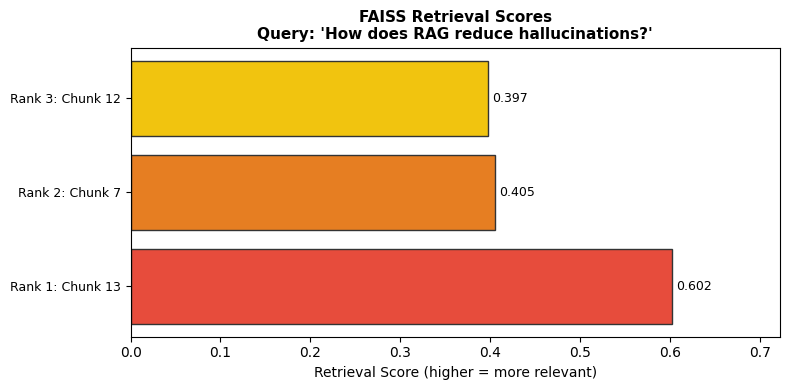

In [22]:
# Visualize retrieval scores as a bar chart
fig, ax = plt.subplots(figsize=(8, 4))

# Convert L2 distance to similarity score (lower distance = more similar)
scores = 1 / (1 + distances[0])
bar_colors = ["#e74c3c", "#e67e22", "#f1c40f"]
labels = [f"Chunk {i+1}\n({chunks[i][:40]}...)" for i in indices[0]]

bars = ax.barh(range(top_k), scores, color=bar_colors, edgecolor="#333")
ax.set_yticks(range(top_k))
ax.set_yticklabels([f"Rank {i+1}: Chunk {indices[0][i]+1}" for i in range(top_k)], fontsize=9)
ax.set_xlabel("Retrieval Score (higher = more relevant)", fontsize=10)
ax.set_title(f"FAISS Retrieval Scores\nQuery: '{query}'", fontsize=11, fontweight="bold")

for bar, score in zip(bars, scores):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"{score:.3f}", va="center", fontsize=9)

ax.set_xlim(0, max(scores) * 1.2)
plt.tight_layout()
plt.show()

---
## Part 5 — Chroma Vector Store

**Chroma** is a developer-friendly local vector database.
Unlike FAISS (which is just an index), Chroma stores the original text alongside embeddings — making retrieval easier.

In [11]:
import chromadb
from chromadb.config import Settings

# Create an in-memory Chroma client
chroma_client = chromadb.Client(Settings(anonymized_telemetry=False))

# Create a collection
collection = chroma_client.create_collection(name="rag_demo1")

# Add all chunks with their embeddings
collection.add(
    documents=chunks,
    embeddings=chunk_embeddings.tolist(),
    ids=["chunk_" + str(i) for i in range(len(chunks))]
)

print("Chroma collection created!")
print("Documents stored:", collection.count())

Chroma collection created!
Documents stored: 13


In [14]:
# Query Chroma — it returns text directly, no manual lookup needed
results = collection.query(
    query_embeddings=query_vec.tolist(),
    n_results=3
)

print("Query:", query)
print()
print("Chroma Top-3 Retrieved Documents:")
print("=" * 60)
for i, (doc, dist) in enumerate(zip(results["documents"][0], results["distances"][0])):
    print(f"Rank {i+1}  |  Distance: {dist:.4f}")
    print(" ", doc)
    print()

print("Advantage of Chroma: returns the actual text, not just an index.")

Query: How does RAG reduce hallucinations?

Chroma Top-3 Retrieved Documents:
Rank 1  |  Distance: 0.6604
  Hallucination in LLMs refers to generating confident but incorrect facts.
RAG is one of the most effective methods to reduce hallucination.

Rank 2  |  Distance: 1.4662
  RAG fetches relevant documents before generating an answer.
This reduces hallucinations and keeps answers grounded in real sources.
Vector databases store embeddings for fast similarity search.

Rank 3  |  Distance: 1.5168
  Re-ranking improves retrieval by scoring candidates with a cross-encoder.
Hallucination in LLMs refers to generating confident but incorrect facts.

Advantage of Chroma: returns the actual text, not just an index.


---
## Part 6 — Re-ranking

**Why re-rank?**
Vector search retrieves by **semantic similarity**, but the top result is not always the most *relevant* answer to the specific question.

**Re-ranking** uses a **cross-encoder** — it scores the query + each chunk *together*, which is slower but much more accurate.

```
Stage 1 (fast):   Vector Search → Top-10 candidates
Stage 2 (precise): Cross-Encoder Re-ranker → Top-3 final results
```

In [15]:
from sentence_transformers import CrossEncoder

# Free cross-encoder model for re-ranking
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

# Retrieve more candidates first (top-6 from FAISS)
distances_broad, indices_broad = index.search(query_vec, 6)
candidate_chunks = [chunks[i] for i in indices_broad[0]]

# Re-rank: score each (query, chunk) pair together
pairs = [[query, chunk] for chunk in candidate_chunks]
rerank_scores = reranker.predict(pairs)

# Sort by re-rank score
ranked_order = np.argsort(rerank_scores)[::-1]

print("Query:", query)
print()
print("After Re-ranking (Cross-Encoder Scores):")
print("=" * 60)
for rank, idx in enumerate(ranked_order):
    marker = "  <-- Top pick" if rank == 0 else ""
    print(f"Rank {rank+1}  |  Score: {rerank_scores[idx]:.4f}{marker}")
    print(" ", candidate_chunks[idx])
    print()

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 3230.96it/s]
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Query: How does RAG reduce hallucinations?

After Re-ranking (Cross-Encoder Scores):
Rank 1  |  Score: 7.2407  <-- Top pick
  RAG fetches relevant documents before generating an answer.
This reduces hallucinations and keeps answers grounded in real sources.
Vector databases store embeddings for fast similarity search.

Rank 2  |  Score: 7.0936
  Hallucination in LLMs refers to generating confident but incorrect facts.
RAG is one of the most effective methods to reduce hallucination.

Rank 3  |  Score: -7.4144
  Re-ranking improves retrieval by scoring candidates with a cross-encoder.
Hallucination in LLMs refers to generating confident but incorrect facts.

Rank 4  |  Score: -8.4563
  LLMs like GPT-4, LLaMA, and Claude can generate human-like text.
Retrieval-Augmented Generation (RAG) combines retrieval with generation.
RAG fetches relevant documents before generating an answer.

Rank 5  |  Score: -11.3887
  Large language models (LLMs) are trained on vast amounts of text data.
LLMs li

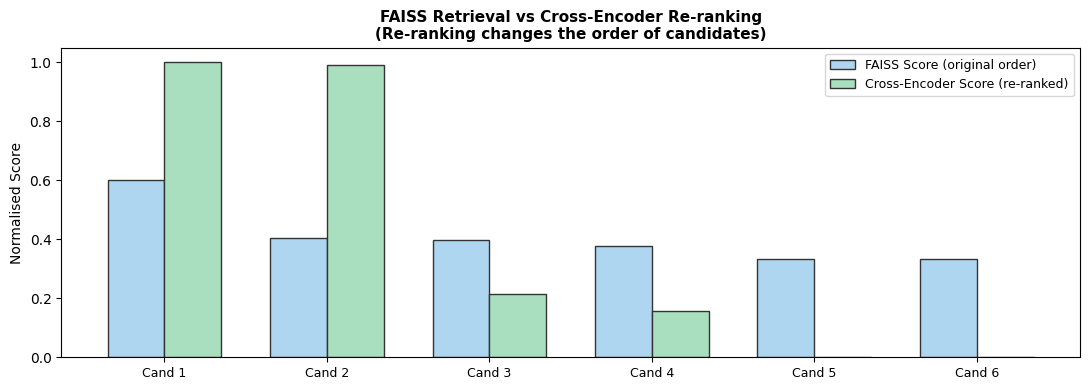

In [27]:
# Compare FAISS order vs Re-ranked order visually
faiss_scores  = 1 / (1 + distances_broad[0])
rerank_norm   = (rerank_scores - rerank_scores.min()) / (rerank_scores.max() - rerank_scores.min() + 1e-9)
reranked_norm = rerank_norm[ranked_order]   # in re-ranked order

x = np.arange(6)
width = 0.35

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(x - width/2, faiss_scores,         width, label="FAISS Score (original order)", color="#aed6f1", edgecolor="#333")
ax.bar(x + width/2, rerank_norm[np.argsort(ranked_order)], width, label="Cross-Encoder Score (re-ranked)", color="#a9dfbf", edgecolor="#333")

ax.set_xticks(x)
ax.set_xticklabels([f"Cand {i+1}" for i in range(6)], fontsize=9)
ax.set_ylabel("Normalised Score", fontsize=10)
ax.set_title("FAISS Retrieval vs Cross-Encoder Re-ranking\n(Re-ranking changes the order of candidates)",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## Part 7 — Hallucination Resistance

**Hallucination** = the LLM confidently states something incorrect or made-up.

**RAG reduces hallucination by:**
- Grounding the answer in retrieved documents
- Explicitly instructing the model: *"Only answer from the context below"*

We simulate this by building a **strict RAG prompt** vs a **no-context prompt** and comparing their structure.

In [16]:
# Build context from top-3 re-ranked chunks
top_chunks = [candidate_chunks[i] for i in ranked_order[:3]]
context = "\n\n".join(["[Chunk " + str(i+1) + "] " + c for i, c in enumerate(top_chunks)])

# RAG prompt (with context — hallucination-resistant)
rag_prompt = """You are a helpful assistant. Answer ONLY using the context below.
If the answer is not in the context, say "I don't know based on the provided documents."

Context:
{context}

Question: {question}

Answer:"""

# No-context prompt (higher hallucination risk)
bare_prompt = """Answer the following question:

Question: {question}

Answer:"""

print("RAG Prompt (with retrieved context):")
print("-" * 50)
print(rag_prompt.format(context=context, question=query))
print()
print("Bare Prompt (no context — hallucination risk):")
print("-" * 50)
print(bare_prompt.format(question=query))

RAG Prompt (with retrieved context):
--------------------------------------------------
You are a helpful assistant. Answer ONLY using the context below.
If the answer is not in the context, say "I don't know based on the provided documents."

Context:
[Chunk 1] RAG fetches relevant documents before generating an answer.
This reduces hallucinations and keeps answers grounded in real sources.
Vector databases store embeddings for fast similarity search.

[Chunk 2] Hallucination in LLMs refers to generating confident but incorrect facts.
RAG is one of the most effective methods to reduce hallucination.

[Chunk 3] Re-ranking improves retrieval by scoring candidates with a cross-encoder.
Hallucination in LLMs refers to generating confident but incorrect facts.

Question: How does RAG reduce hallucinations?

Answer:

Bare Prompt (no context — hallucination risk):
--------------------------------------------------
Answer the following question:

Question: How does RAG reduce hallucinations?


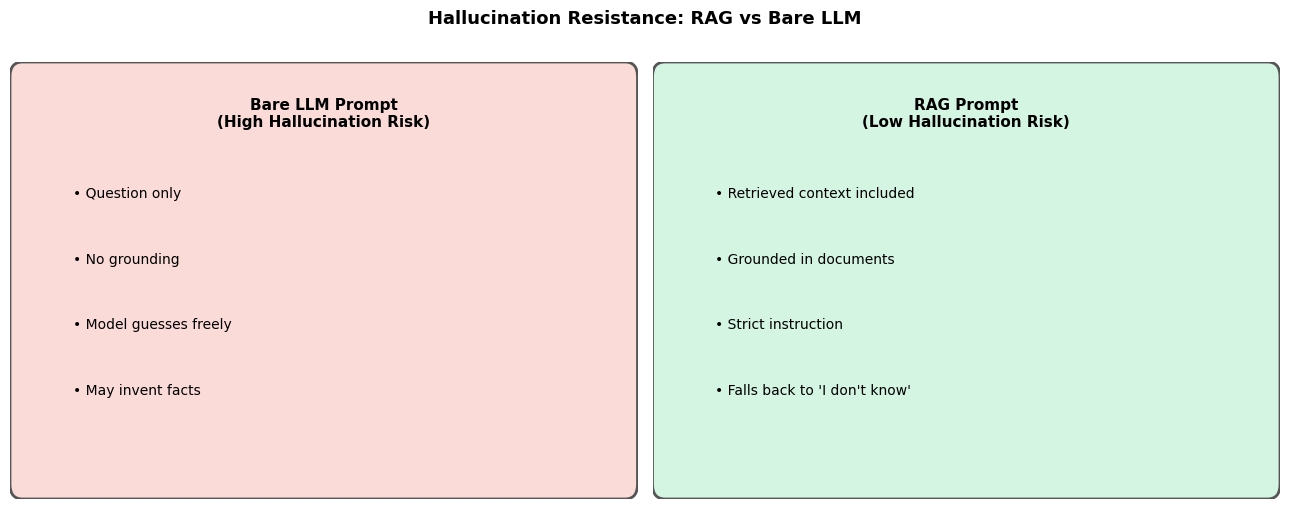

In [29]:
# Visualize: what makes a prompt hallucination-resistant
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

prompt_types = [
    ("Bare LLM Prompt\n(High Hallucination Risk)", "#fadbd8",
     ["Question only", "No grounding", "Model guesses freely", "May invent facts"]),
    ("RAG Prompt\n(Low Hallucination Risk)", "#d5f5e3",
     ["Retrieved context included", "Grounded in documents", "Strict instruction", "Falls back to 'I don't know'"]),
]

for ax, (title, color, points) in zip(axes, prompt_types):
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 6)
    ax.axis("off")
    ax.set_facecolor(color)
    fig.patch.set_facecolor("white")
    rect = mpatches.FancyBboxPatch((0.2, 0.2), 9.6, 5.6,
        boxstyle="round,pad=0.2", linewidth=2,
        edgecolor="#555", facecolor=color)
    ax.add_patch(rect)
    ax.text(5, 5.3, title, ha="center", va="center",
            fontsize=11, fontweight="bold")
    for i, point in enumerate(points):
        ax.text(1, 4.2 - i * 0.9, "• " + point, va="center", fontsize=10)

plt.suptitle("Hallucination Resistance: RAG vs Bare LLM",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

---
## Part 8 — End-to-End RAG Pipeline in LangChain

We now wire everything together using LangChain:
1. **Embed** documents with HuggingFace embeddings
2. **Store** in a FAISS vector store (via LangChain)
3. **Retrieve** top-k chunks at query time
4. **Generate** an answer using a free HuggingFace model

In [17]:
from langchain_community.vectorstores import FAISS as LangFAISS
from langchain_huggingface import HuggingFaceEmbeddings
# from langchain.schema import Document
from langchain_core.documents import Document

# Wrap chunks as LangChain Documents
documents = [Document(page_content=chunk) for chunk in chunks]

# Use HuggingFace embeddings (free)
hf_embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

# Build FAISS vector store from documents
vector_store = LangFAISS.from_documents(documents, hf_embeddings)

print("LangChain FAISS vector store built!")
print("Documents indexed:", len(documents))

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6930.84it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


LangChain FAISS vector store built!
Documents indexed: 13


In [18]:
# Build a retriever from the vector store
retriever = vector_store.as_retriever(search_kwargs={"k": 3})

# Retrieve relevant chunks for our query
retrieved_docs = retriever.invoke(query)

print("Query:", query)
print()
print("LangChain Retriever — Top 3 Results:")
print("=" * 60)
for i, doc in enumerate(retrieved_docs):
    print(f"Result {i+1}: {doc.page_content}")
    print()

Query: How does RAG reduce hallucinations?

LangChain Retriever — Top 3 Results:
Result 1: Hallucination in LLMs refers to generating confident but incorrect facts.
RAG is one of the most effective methods to reduce hallucination.

Result 2: RAG fetches relevant documents before generating an answer.
This reduces hallucinations and keeps answers grounded in real sources.
Vector databases store embeddings for fast similarity search.

Result 3: Re-ranking improves retrieval by scoring candidates with a cross-encoder.
Hallucination in LLMs refers to generating confident but incorrect facts.



In [19]:
# Retrieval precision evaluation: how many retrieved chunks are actually relevant?
# We label relevance manually for this small demo

relevant_keywords = ["hallucination", "RAG", "retrieval", "augmented", "grounded", "reduces"]

def is_relevant(text, keywords):
    text_lower = text.lower()
    return any(kw.lower() in text_lower for kw in keywords)

print("Retrieval Precision Evaluation")
print("=" * 55)
print(f"{'Rank':<6} {'Relevant?':<12} {'Chunk Preview'}")
print("-" * 55)

relevant_count = 0
for i, doc in enumerate(retrieved_docs):
    relevant = is_relevant(doc.page_content, relevant_keywords)
    if relevant:
        relevant_count += 1
    flag = "YES" if relevant else "NO"
    print(f"{i+1:<6} {flag:<12} {doc.page_content[:55]}...")

precision = relevant_count / len(retrieved_docs)
print()
print(f"Retrieval Precision: {relevant_count}/{len(retrieved_docs)} = {precision:.2f}")
print()
print("Tip: Higher precision means fewer irrelevant chunks reach the LLM.")

Retrieval Precision Evaluation
Rank   Relevant?    Chunk Preview
-------------------------------------------------------
1      YES          Hallucination in LLMs refers to generating confident bu...
2      YES          RAG fetches relevant documents before generating an ans...
3      YES          Re-ranking improves retrieval by scoring candidates wit...

Retrieval Precision: 3/3 = 1.00

Tip: Higher precision means fewer irrelevant chunks reach the LLM.
